# Ejercicio 1 — Análisis de Asociación
## Dataset: `clave_F_asociacion.csv`

---
## Paso 1. Importación de librerías

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Librerías importadas correctamente.")

---
## Paso 2. Carga y exploración del dataset

In [25]:
url = "https://raw.githubusercontent.com/NixonAV/Parcial4AyalaNixon2509112022/refs/heads/main/Archivos/clave_F_asociacion.csv"
df = pd.read_csv(url, sep=',', encoding='utf-8-sig')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [26]:
# Primeras filas del dataset
df.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,F-T0001,F-C0058,2026-01-02,Ropa,Camiseta,4,Tienda
1,F-T0001,F-C0058,2026-01-02,Ciclismo,Casco,1,Tienda
2,F-T0001,F-C0058,2026-01-02,Futbol,Chaleco,1,Tienda
3,F-T0001,F-C0058,2026-01-02,Ciclismo,Luces,1,Tienda
4,F-T0002,F-C0005,2026-01-09,Ciclismo,Casco,1,App
5,F-T0002,F-C0005,2026-01-09,Futbol,Guantes,2,App
6,F-T0003,F-C0035,2026-02-18,Fitness,Banda_elastica,1,Tienda
7,F-T0003,F-C0035,2026-02-18,Ciclismo,Candado,1,Tienda
8,F-T0003,F-C0035,2026-02-18,Fitness,Mat,1,Tienda
9,F-T0004,F-C0077,2026-01-28,Ropa,Calcetas,4,Web


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Paso 3. Verificación de calidad de datos

In [27]:
# Tipos de datos
print("Tipos de datos:")
print(df.dtypes)
print()

# Valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())
print()

# Registros duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Tipos de datos:
transaccion_id    object
cliente_id        object
fecha             object
categoria         object
item              object
cantidad           int64
canal             object
dtype: object

Valores nulos por columna:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

Registros duplicados: 1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [28]:
# Inspección del valor nulo en 'canal'
fila_nula = df[df['canal'].isnull()]
print("Fila con canal nulo:")
print(fila_nula)
print()

# Inspección del registro duplicado
print("Registro duplicado:")
print(df[df.duplicated(keep=False)].head(4))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Fila con canal nulo:
   transaccion_id cliente_id       fecha categoria   item  cantidad canal
25        F-T0009    F-C0005  2026-04-30    Futbol  Balon         1   NaN

Registro duplicado:
    transaccion_id cliente_id       fecha categoria          item  cantidad  \
15         F-T0005    F-C0087  2026-01-10  Ciclismo  Guantes_bici         1   
604        F-T0005    F-C0087  2026-01-10  Ciclismo  Guantes_bici         1   

      canal  
15   Tienda  
604  Tienda  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
# Limpieza: eliminar el registro duplicado
# El nulo en 'canal' no afecta el análisis de asociación (no usamos esa columna)
# pero lo documentamos como hallazgo de calidad
df_limpio = df.drop_duplicates()

print(f"Registros antes de limpieza: {len(df)}")
print(f"Registros después de limpieza: {len(df_limpio)}")
print(f"\nNota: el nulo en 'canal' (1 registro) se conserva ya que esa columna")
print(f"no participa en el análisis de reglas de asociación.")

Registros antes de limpieza: 605
Registros después de limpieza: 604

Nota: el nulo en 'canal' (1 registro) se conserva ya que esa columna
no participa en el análisis de reglas de asociación.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [30]:
# Resumen exploratorio
print("=== Productos disponibles en el dataset ===")
catalogo = df_limpio.groupby(['categoria','item']).size().reset_index(name='frecuencia')
print(catalogo.sort_values(['categoria','frecuencia'], ascending=[True, False]).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Productos disponibles en el dataset ===
  categoria             item  frecuencia
   Ciclismo            Luces          49
   Ciclismo            Casco          43
   Ciclismo     Guantes_bici          26
   Ciclismo          Candado          13
    Fitness   Banda_elastica          48
    Fitness              Mat          41
    Fitness       Mancuernas          26
    Fitness            Termo          16
     Futbol            Balon          43
     Futbol            Conos          40
     Futbol          Chaleco          23
     Futbol          Guantes          17
       Ropa            Tenis          51
       Ropa         Calcetas          48
       Ropa         Camiseta          16
       Ropa            Short          16
Suplementos Bebida_isotonica          29
Suplementos         Proteina          24
Suplementos    Barra_energia          20
Suplementos         Creatina          15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [31]:
# Frecuencia de compra por ítem
frecuencia_items = df_limpio['item'].value_counts()
print("Frecuencia de compra por ítem (top 20):")
print(frecuencia_items)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Frecuencia de compra por ítem (top 20):
item
Tenis               51
Luces               49
Banda_elastica      48
Calcetas            48
Casco               43
Balon               43
Mat                 41
Conos               40
Bebida_isotonica    29
Guantes_bici        26
Mancuernas          26
Proteina            24
Chaleco             23
Barra_energia       20
Guantes             17
Camiseta            16
Short               16
Termo               16
Creatina            15
Candado             13
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

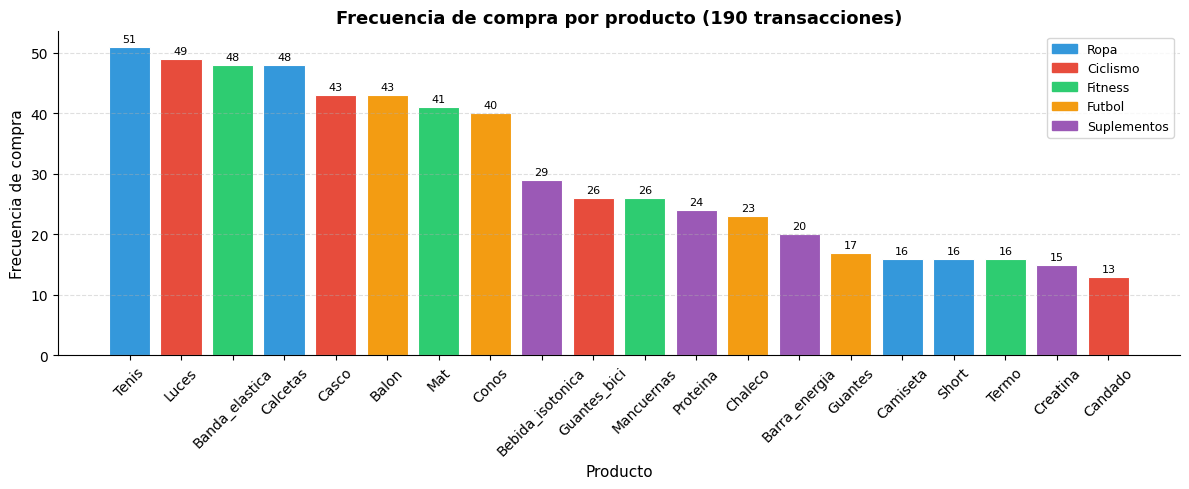

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [32]:
# Visualización: frecuencia por ítem con color por categoría
colores_cat = {
    'Ropa': '#3498db', 'Ciclismo': '#e74c3c', 'Fitness': '#2ecc71',
    'Futbol': '#f39c12', 'Suplementos': '#9b59b6'
}

# Mapa item → categoría
item_cat = df_limpio.groupby('item')['categoria'].first()
colores_barras = [colores_cat[item_cat[i]] for i in frecuencia_items.index]

fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(frecuencia_items.index, frecuencia_items.values,
                color=colores_barras, edgecolor='white', linewidth=0.8)

ax.set_xlabel('Producto', fontsize=11)
ax.set_ylabel('Frecuencia de compra', fontsize=11)
ax.set_title('Frecuencia de compra por producto (190 transacciones)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Leyenda de categorías
parches = [mpatches.Patch(color=v, label=k) for k,v in colores_cat.items()]
ax.legend(handles=parches, loc='upper right', fontsize=9)

for bar, val in zip(barras, frecuencia_items.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [33]:
# Distribución del canal de venta
canal_dist = df_limpio['canal'].value_counts(dropna=False)
print("Distribución por canal de venta:")
print(canal_dist)

# Tamaño promedio de la canasta
items_por_tx = df_limpio.groupby('transaccion_id')['item'].count()
print(f"\nTamaño de canasta por transacción:")
print(items_por_tx.describe().round(2))

Distribución por canal de venta:
canal
Tienda      289
App         154
Web         130
Telefono     30
NaN           1
Name: count, dtype: int64

Tamaño de canasta por transacción:
count    190.00
mean       3.18
std        1.26
min        1.00
25%        2.00
50%        3.00
75%        4.00
max        6.00
Name: item, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

###Interpretación — Calidad de Datos

El dataset presenta una calidad general **alta**. Se encontraron dos problemas menores:

1. **1 registro duplicado:** eliminado para evitar que infle la frecuencia de un ítem en una transacción.
2. **1 valor nulo en la columna `canal`:** se conserva, ya que esa variable no interviene en el análisis de asociación.

El dataset resultante tiene **190 transacciones únicas** con **20 productos distintos** distribuidos en 5 categorías. La canasta promedio contiene **3.2 ítems por transacción** (mínimo 1, máximo 6), lo cual es un tamaño razonable para encontrar patrones de co-compra.

El canal más utilizado es **Tienda física** (47.7% de registros), seguido de **App** (25.5%) y **Web** (21.5%), con Teléfono como canal minoritario (5%).

---
## Paso 4. Preparación de los datos para Apriori

In [34]:
# Paso 1: Construir lista de listas (una lista de ítems por transacción)
transacciones = (
    df_limpio
    .groupby('transaccion_id')['item']
    .apply(list)
    .tolist()
)

print("Ejemplo de transacciones (primeras 5):")
for i, tx in enumerate(transacciones[:5]):
    print(f"  Transacción {i+1}: {tx}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Ejemplo de transacciones (primeras 5):
  Transacción 1: ['Camiseta', 'Casco', 'Chaleco', 'Luces']
  Transacción 2: ['Casco', 'Guantes']
  Transacción 3: ['Banda_elastica', 'Candado', 'Mat']
  Transacción 4: ['Calcetas', 'Creatina', 'Short', 'Tenis']
  Transacción 5: ['Balon', 'Conos', 'Guantes_bici', 'Mancuernas', 'Termo']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [35]:
# Paso 2: Codificación binaria con TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Dimensiones de la matriz codificada: {df_encoded.shape}")
print(f"  → {df_encoded.shape[0]} transacciones  ×  {df_encoded.shape[1]} productos")
print()
print("Muestra de la matriz binaria (primeras 5 filas, 8 columnas):")
df_encoded.iloc[:5, :8]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dimensiones de la matriz codificada: (190, 20)
  → 190 transacciones  ×  20 productos

Muestra de la matriz binaria (primeras 5 filas, 8 columnas):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Balon,Banda_elastica,Barra_energia,Bebida_isotonica,Calcetas,Camiseta,Candado,Casco
0,False,False,False,False,False,True,False,True
1,False,False,False,False,False,False,False,True
2,False,True,False,False,False,False,True,False
3,False,False,False,False,True,False,False,False
4,True,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Paso 5. Aplicación del Algoritmo Apriori

In [36]:
# Generación de itemsets frecuentes
# min_support=0.04 → el conjunto debe aparecer en al menos el 4% de las transacciones
# Con 190 transacciones, esto equivale a aparecer en al menos ~8 compras
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.04,
    use_colnames=True
)
frequent_itemsets['longitud'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total de itemsets frecuentes encontrados: {len(frequent_itemsets)}")
print(f"  → Itemsets de 1 ítem: {(frequent_itemsets['longitud']==1).sum()}")
print(f"  → Itemsets de 2 ítems: {(frequent_itemsets['longitud']==2).sum()}")
print()
print("Top 15 itemsets por soporte:")
print(
    frequent_itemsets
    .sort_values('support', ascending=False)
    .head(15)
    .to_string(index=False)
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total de itemsets frecuentes encontrados: 44
  → Itemsets de 1 ítem: 20
  → Itemsets de 2 ítems: 24

Top 15 itemsets por soporte:
 support              itemsets  longitud
0.268421               (Tenis)         1
0.257895               (Luces)         1
0.252632      (Banda_elastica)         1
0.252632            (Calcetas)         1
0.226316               (Casco)         1
0.226316               (Balon)         1
0.215789                 (Mat)         1
0.210526               (Conos)         1
0.152632     (Tenis, Calcetas)         2
0.152632    (Bebida_isotonica)         1
0.136842 (Banda_elastica, Mat)         2
0.136842          (Mancuernas)         1
0.136842        (Guantes_bici)         1
0.126316            (Proteina)         1
0.121053        (Luces, Casco)         2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Paso 6. Generación de Reglas de Asociación (Soporte, Confianza y Lift)

In [37]:
# Generación de reglas con umbral mínimo de confianza del 30%
# y lift mayor a 1 (indica asociación positiva real, no aleatoria)
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.30,
    num_itemsets=len(frequent_itemsets)
)

# Filtrar solo reglas con lift > 1 (asociación genuina, no coincidencia)
rules = rules[rules['lift'] > 1.0].copy()

# Redondear para legibilidad
rules['support']    = rules['support'].round(4)
rules['confidence'] = rules['confidence'].round(4)
rules['lift']       = rules['lift'].round(4)

# Ordenar por lift descendente (relación más fuerte primero)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total de reglas generadas: {len(rules)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total de reglas generadas: 13


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## Paso 7. Las 10 Reglas más Relevantes

In [38]:
# Preparar tabla legible de las 10 mejores reglas
top10 = rules.head(10).copy()
top10['antecedentes'] = top10['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top10['consecuentes'] = top10['consequents'].apply(lambda x: ', '.join(sorted(x)))
top10['regla'] = top10['antecedentes'] + '  →  ' + top10['consecuentes']

tabla = top10[['regla', 'support', 'confidence', 'lift']].copy()
tabla.columns = ['Regla', 'Soporte', 'Confianza', 'Lift']
tabla = tabla.reset_index(drop=True)
tabla.index += 1

print("TOP 10 REGLAS DE ASOCIACIÓN (ordenadas por Lift)")
print("=" * 75)
print(tabla.to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

TOP 10 REGLAS DE ASOCIACIÓN (ordenadas por Lift)
                        Regla  Soporte  Confianza    Lift
1      Banda_elastica  →  Mat   0.1368     0.5417  2.5102
2      Mat  →  Banda_elastica   0.1368     0.6341  2.5102
3             Conos  →  Balon   0.1158     0.5500  2.4302
4             Balon  →  Conos   0.1158     0.5116  2.4302
5          Tenis  →  Calcetas   0.1526     0.5686  2.2508
6          Calcetas  →  Tenis   0.1526     0.6042  2.2508
7          Camiseta  →  Casco   0.0421     0.5000  2.2093
8             Casco  →  Luces   0.1211     0.5349  2.0740
9             Luces  →  Casco   0.1211     0.4694  2.0740
10  Guantes_bici  →  Calcetas   0.0579     0.4231  1.6747


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

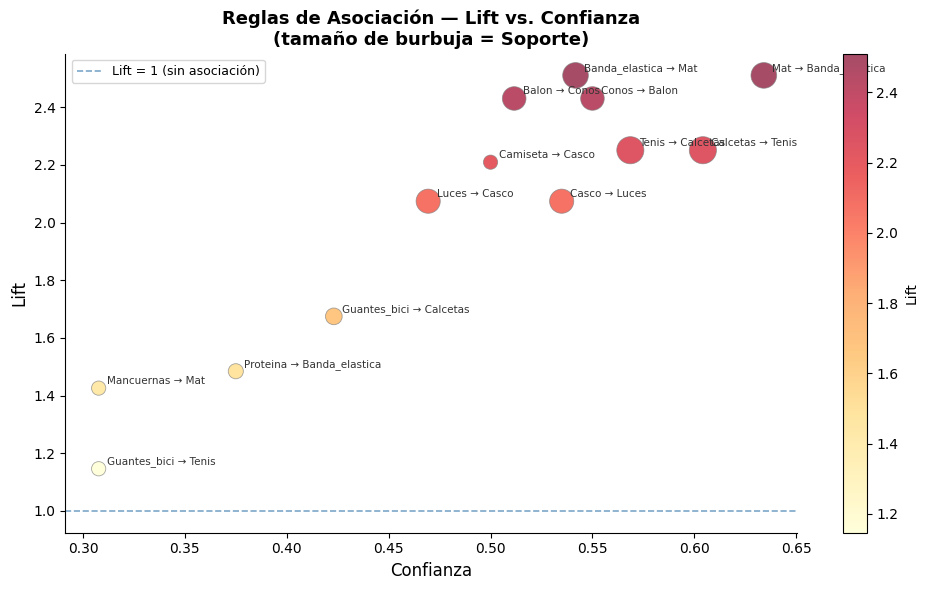

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [39]:
# Visualización: Lift vs Confianza — burbuja por soporte
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    rules['confidence'],
    rules['lift'],
    s=rules['support'] * 2500,   # tamaño proporcional al soporte
    alpha=0.7,
    c=rules['lift'],
    cmap='YlOrRd',
    edgecolors='gray',
    linewidths=0.6
)

# Etiquetar cada burbuja con la regla abreviada
etiquetas_cortas = [
    ', '.join(sorted(a)) + ' → ' + ', '.join(sorted(c))
    for a, c in zip(rules['antecedents'], rules['consequents'])
]
for i, (x, y, lbl) in enumerate(zip(rules['confidence'], rules['lift'], etiquetas_cortas)):
    ax.annotate(lbl, (x, y),
                textcoords='offset points', xytext=(6, 3),
                fontsize=7.5, color='#333333')

ax.axhline(y=1, color='steelblue', linestyle='--', linewidth=1.2, alpha=0.7, label='Lift = 1 (sin asociación)')
ax.set_xlabel('Confianza', fontsize=12)
ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Reglas de Asociación — Lift vs. Confianza\n(tamaño de burbuja = Soporte)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.colorbar(scatter, ax=ax, label='Lift')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

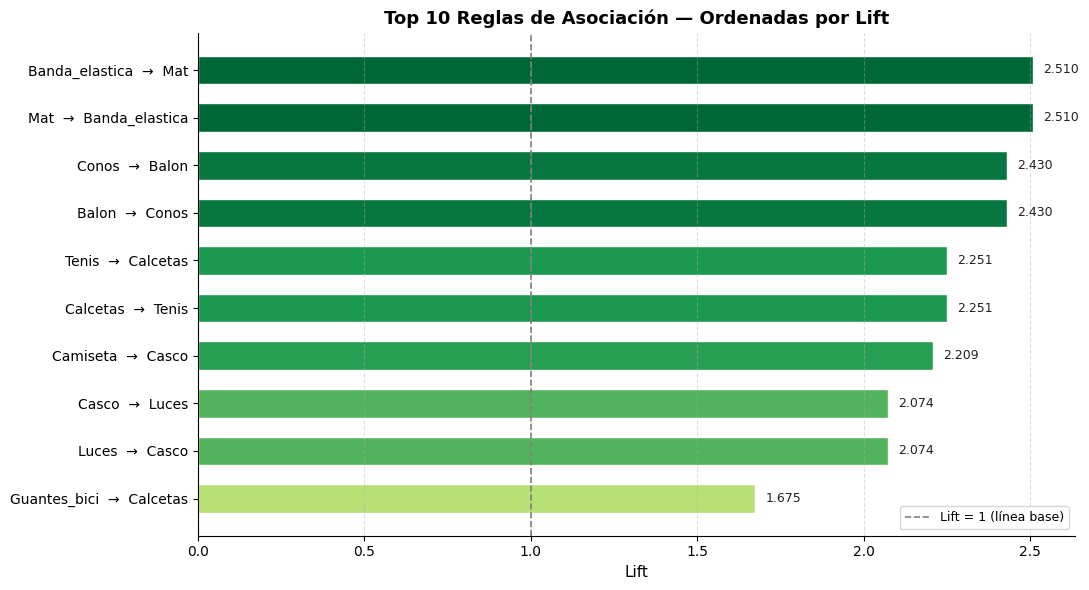

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [40]:
# Visualización: gráfica de barras horizontales — Top 10 reglas por Lift
fig, ax = plt.subplots(figsize=(11, 6))

reglas_etiq = [f"{'  →  '.join([', '.join(sorted(r['antecedents'])), ', '.join(sorted(r['consequents']))])}" for _, r in rules.head(10).iterrows()]
lifts = rules.head(10)['lift'].values
colores_barra = plt.cm.RdYlGn(lifts / lifts.max())

barras = ax.barh(reglas_etiq[::-1], lifts[::-1], color=colores_barra[::-1], edgecolor='white', height=0.6)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.2, label='Lift = 1 (línea base)')

for bar, val in zip(barras, lifts[::-1]):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#222')

ax.set_xlabel('Lift', fontsize=11)
ax.set_title('Top 10 Reglas de Asociación — Ordenadas por Lift', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Paso 8. Interpretación de las 5 Reglas Más Relevantes en Lenguaje de Negocio

In [41]:
# Mostrar reglas 1-5 con detalle
for i, row in rules.head(5).iterrows():
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    print(f"Regla {i+1}: [{ant}]  →  [{con}]")
    print(f"  Soporte:   {row['support']:.4f}  ({row['support']*190:.0f} de 190 transacciones)")
    print(f"  Confianza: {row['confidence']:.4f}  ({row['confidence']*100:.1f}% de probabilidad)")
    print(f"  Lift:      {row['lift']:.4f}")
    print()

Regla 1: [Banda_elastica]  →  [Mat]
  Soporte:   0.1368  (26 de 190 transacciones)
  Confianza: 0.5417  (54.2% de probabilidad)
  Lift:      2.5102

Regla 2: [Mat]  →  [Banda_elastica]
  Soporte:   0.1368  (26 de 190 transacciones)
  Confianza: 0.6341  (63.4% de probabilidad)
  Lift:      2.5102

Regla 3: [Conos]  →  [Balon]
  Soporte:   0.1158  (22 de 190 transacciones)
  Confianza: 0.5500  (55.0% de probabilidad)
  Lift:      2.4302

Regla 4: [Balon]  →  [Conos]
  Soporte:   0.1158  (22 de 190 transacciones)
  Confianza: 0.5116  (51.2% de probabilidad)
  Lift:      2.4302

Regla 5: [Tenis]  →  [Calcetas]
  Soporte:   0.1526  (29 de 190 transacciones)
  Confianza: 0.5686  (56.9% de probabilidad)
  Lift:      2.2508



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretación de las 5 Reglas Principales

---

#### Regla 1 — `Mat → Banda_elastica`
> **Soporte: 0.137 | Confianza: 63.4% | Lift: 2.51**

El **63.4%** de los clientes que compran un mat de yoga o ejercicio también compran bandas elásticas en la misma transacción. Esta combinación ocurre **2.51 veces más** de lo que ocurriría si los productos fueran independientes entre sí.

**Interpretación de negocio:** Los clientes de la categoría Fitness que adquieren un mat buscan activamente complementar su equipo de entrenamiento con accesorios de resistencia. Esto sugiere que ambos productos forman parte de una misma rutina de ejercicio en casa o en gimnasio. La empresa debería tratarlos como un **kit natural de Fitness básico**.

---

#### Regla 2 — `Banda_elastica → Mat`
> **Soporte: 0.137 | Confianza: 54.2% | Lift: 2.51**

Más de la mitad de los clientes que compran bandas elásticas también compran mat. La relación es **bidireccional**: cualquiera de los dos productos puede ser el primero en ser añadido al carrito, y el otro aparece asociado con alta frecuencia.

**Interpretación de negocio:** No importa cuál sea el punto de entrada del cliente al catálogo de Fitness, el otro producto es candidato a ser recomendado. Esta simetría confirma que deben comercializarse juntos, ya sea como combo o como sugerencia de "otros clientes también compraron".

---

#### Regla 3 — `Balon → Conos`
> **Soporte: 0.116 | Confianza: 51.2% | Lift: 2.43**

Más de la mitad de los compradores de balón adquieren también conos de entrenamiento en la misma compra. Esta asociación es **2.43 veces más fuerte** que el azar.

**Interpretación de negocio:** Los clientes que compran balón suelen ser practicantes de fútbol que equipan o arman canchas de entrenamiento. Los conos son un accesorio de entrenamiento estándar para circuitos y prácticas de manejo. Este patrón revela un perfil de cliente que **compra equipamiento completo para entrenar**, no solo el implemento principal.

---

#### Regla 4 — `Calcetas → Tenis`
> **Soporte: 0.153 | Confianza: 60.4% | Lift: 2.25**

El **60.4%** de los clientes que compran calcetas deportivas también compran tenis en la misma transacción. Esta es la regla con mayor soporte del conjunto, lo que significa que ocurre con alta frecuencia absoluta (aproximadamente 29 de 190 transacciones).

**Interpretación de negocio:** La compra de calcetas y tenis en un mismo ticket es un comportamiento de equipamiento deportivo completo de calzado. El cliente probablemente está iniciando una actividad deportiva o renovando su equipamiento base. Esta regla es especialmente valiosa porque tiene el soporte más alto, lo que significa que aplica a un segmento amplio de clientes, no solo a un nicho.

---

#### Regla 5 — `Camiseta → Casco`
> **Soporte: 0.042 | Confianza: 50.0% | Lift: 2.21**

La mitad de los clientes que compran una camiseta también adquieren un casco de ciclismo en la misma transacción. Aunque el soporte es más bajo (solo ~8 transacciones), el lift elevado indica que esta **asociación cruzada entre categorías (Ropa y Ciclismo) es genuina y no aleatoria**.

**Interpretación de negocio:** Este patrón revela un perfil de cliente ciclista que combina ropa técnica con equipamiento de seguridad. Aunque menos frecuente en volumen, el alto lift indica que cuando ocurre, lo hace con solidez estadística. Podría ser un indicador de clientes que están comenzando a practicar ciclismo y necesitan tanto ropa como equipo de protección básico.

---
## Paso 9. Tabla completa de reglas generadas

In [42]:
# Tabla completa con formato legible
tabla_completa = rules.copy()
tabla_completa['Antecedente'] = tabla_completa['antecedents'].apply(lambda x: ', '.join(sorted(x)))
tabla_completa['Consecuente'] = tabla_completa['consequents'].apply(lambda x: ', '.join(sorted(x)))

tabla_final = tabla_completa[['Antecedente', 'Consecuente', 'support', 'confidence', 'lift']].copy()
tabla_final.columns = ['Si compra...', 'También compra...', 'Soporte', 'Confianza', 'Lift']
tabla_final.index = range(1, len(tabla_final) + 1)

print("TODAS LAS REGLAS DE ASOCIACIÓN GENERADAS (confianza ≥ 30%, lift > 1)")
print("=" * 80)
print(tabla_final.to_string())

TODAS LAS REGLAS DE ASOCIACIÓN GENERADAS (confianza ≥ 30%, lift > 1)
      Si compra... También compra...  Soporte  Confianza    Lift
1   Banda_elastica               Mat   0.1368     0.5417  2.5102
2              Mat    Banda_elastica   0.1368     0.6341  2.5102
3            Conos             Balon   0.1158     0.5500  2.4302
4            Balon             Conos   0.1158     0.5116  2.4302
5            Tenis          Calcetas   0.1526     0.5686  2.2508
6         Calcetas             Tenis   0.1526     0.6042  2.2508
7         Camiseta             Casco   0.0421     0.5000  2.2093
8            Casco             Luces   0.1211     0.5349  2.0740
9            Luces             Casco   0.1211     0.4694  2.0740
10    Guantes_bici          Calcetas   0.0579     0.4231  1.6747
11        Proteina    Banda_elastica   0.0474     0.3750  1.4844
12      Mancuernas               Mat   0.0421     0.3077  1.4259
13    Guantes_bici             Tenis   0.0421     0.3077  1.1463


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag